**1. Tugas 1**: Jalankan kode di atas dan buat modifikasi dengan menambahkan data lain berupa kolom pekerjaan, hobi dan gender.

- Untuk melakukan modifikasi pada data dibawah, di variabel data akan dimasukkan data berdasarkan atribut dari setiap orang, berurutan sesuai dengan urutan variabel columns. Sama halnya untuk columns, modifikasi kolom akan ditambahkan kolom pekerjaan, hobi, dan gender sesuai urutan.

In [1]:
from pyspark.sql import SparkSession

# Memulai Spark session
spark = SparkSession.builder.appName("BigDataPractice").getOrCreate()

# Membuat DataFrame sederhana
data = [("Ali", 34, "Tukang Sate", "Nyate", "Laki-laki"), ("Budi", 23, "Perenang", "Berenang", "Laki-laki"), ("Citra", 29, "Perias", "Sepak bola", "Perempuan"), ("Dina", 45, "Bakul Ayam", "Merawat Ayam", "Perempuan")]
columns = ["Nama", "Usia", "Pekerjaan", "Hobi", "Gender"]
df = spark.createDataFrame(data, columns)

# Menampilkan DataFrame
df.show()


+-----+----+-----------+------------+---------+
| Nama|Usia|  Pekerjaan|        Hobi|   Gender|
+-----+----+-----------+------------+---------+
|  Ali|  34|Tukang Sate|       Nyate|Laki-laki|
| Budi|  23|   Perenang|    Berenang|Laki-laki|
|Citra|  29|     Perias|  Sepak bola|Perempuan|
| Dina|  45| Bakul Ayam|Merawat Ayam|Perempuan|
+-----+----+-----------+------------+---------+



**2.  Tugas 2**: Lakukan filter, penghitungan rata-rata, dan pengurutan data menggunakan PySpark.

- Untuk melakukan filter, disini menggunakan data sebelumnya dan menggunakan metode df.filter, secara langsung akan menampilkan orang-orang diatas usia 30. <br>
- Untuk penghitungan rata-rata usia, menggunakan metode df.groupBy().agg, ini akan mengelompokkan usia kemudian mencari rata-ratanya. <br>
- Terakhir, untuk pengurutan data dari usia paling tua hingga muda, menggunakan metode df.orderBy("kolom", ascending=false)

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import avg

# Memulai Spark session
spark = SparkSession.builder.appName("BigDataPractice").getOrCreate()

# Membuat DataFrame sederhana
data = [("Ali", 34, "Tukang Sate", "Nyate", "Laki-laki"), ("Budi", 23, "Perenang", "Berenang", "Laki-laki"), ("Citra", 29, "Perias", "Sepak bola", "Perempuan"), ("Dina", 45, "Bakul Ayam", "Merawat Ayam", "Perempuan")]
columns = ["Nama", "Usia", "Pekerjaan", "Hobi", "Gender"]
df = spark.createDataFrame(data, columns)

# Menampilkan DataFrame
df.show()

# Filtering data
df_filtered = df.filter(df['Usia'] > 30)
df_filtered.show()

# Menghitung rata-rata usia
from pyspark.sql.functions import avg
df.groupBy().agg(avg("Usia")).show()

# Mengurutkan data berdasarkan usia
df_sorted = df.orderBy("Usia", ascending=False)
df_sorted.show()


+-----+----+-----------+------------+---------+
| Nama|Usia|  Pekerjaan|        Hobi|   Gender|
+-----+----+-----------+------------+---------+
|  Ali|  34|Tukang Sate|       Nyate|Laki-laki|
| Budi|  23|   Perenang|    Berenang|Laki-laki|
|Citra|  29|     Perias|  Sepak bola|Perempuan|
| Dina|  45| Bakul Ayam|Merawat Ayam|Perempuan|
+-----+----+-----------+------------+---------+

+----+----+-----------+------------+---------+
|Nama|Usia|  Pekerjaan|        Hobi|   Gender|
+----+----+-----------+------------+---------+
| Ali|  34|Tukang Sate|       Nyate|Laki-laki|
|Dina|  45| Bakul Ayam|Merawat Ayam|Perempuan|
+----+----+-----------+------------+---------+

+---------+
|avg(Usia)|
+---------+
|    32.75|
+---------+

+-----+----+-----------+------------+---------+
| Nama|Usia|  Pekerjaan|        Hobi|   Gender|
+-----+----+-----------+------------+---------+
| Dina|  45| Bakul Ayam|Merawat Ayam|Perempuan|
|  Ali|  34|Tukang Sate|       Nyate|Laki-laki|
|Citra|  29|     Perias|  Sepak

**3. Tugas 3**: Modifikasi DataFrame Pandas dengan menambahkan kolom baru dan melakukan operasi seperti filtering data berdasarkan usia.

- Dataframe Pandas memiliki struktur yang berbeda dari Dataframe sebelumnya. Untuk memasukkan data dengan benar pada DataFrame Pandas, data-data dimasukkan pada variabel data_pandas dan diurutkan berdasarkan {"kolom": [data x, data y, data z]} dan seterusnya.

In [3]:
import pandas as pd

# Membuat DataFrame Pandas
data_pandas = {"Nama": ["Ali", "Budi", "Citra", "Dina"], "Usia": [34, 23, 29, 45], "Pekerjaan" : ["Bakul Ayam","Tukang Sate","Perias","Perenang"],"Hobi" :["Merawat Ayam","Nyate","Sepak Bola","Berenang"],"Gender":["Perempuan","Laki-laki","Perempuan","Laki-laki"]}
df_pandas = pd.DataFrame(data_pandas)

# Menampilkan DataFrame Pandas
df_pandas

,Nama,Usia,Pekerjaan,Hobi,Gender
0,Ali,34,Bakul Ayam,Merawat Ayam,Perempuan
1,Budi,23,Tukang Sate,Nyate,Laki-laki
2,Citra,29,Perias,Sepak Bola,Perempuan
3,Dina,45,Perenang,Berenang,Laki-laki


**4. Tugas 4**: Lakukan penggabungan DataFrame dan visualisasikan data dengan Pandas.

- Pada data dibawah, data-data telah dipisah ke dalam dua variabel, variabel data_pandas dan variabel data_pandas_2. Kedua variabel memiliki dua hal yang sama yaitu sama-sama memiliki kolom nama. untuk menggabungkan kedua variabel tersebut, gunakan kolom nama sebagai target penggabungan data menggunakan kode pd.merge(variabel_1, variabel_2, on="KolomTarget").
- Untuk memvisualisasikan Data tersebut, disini kolom usia menjadi target untuk dibuatkan grafik berdasarkan usia. Menggunakan modul matplotlib, ini memungkinkan untuk membuat grafik berdasarkan kolom yang diinginkan.

    Nama  Usia    Pekerjaan
0    Ali    34   Bakul Ayam
1   Budi    23  Tukang Sate
2  Citra    29       Perias
3   Dina    45     Perenang
            Usia
count   4.000000
mean   32.750000
std     9.322911
min    23.000000
25%    27.500000
50%    31.500000
75%    36.750000
max    45.000000


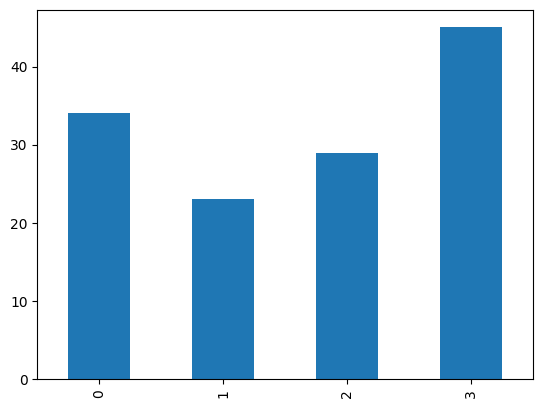

In [4]:
import pandas as pd

# Membuat DataFrame Pandas
data_pandas = {"Nama": ["Ali", "Budi", "Citra", "Dina"], "Usia": [34, 23, 29, 45]}
df_pandas = pd.DataFrame(data_pandas)

# Membuat DataFrame kedua
data_pandas_2 = {"Nama": ["Ali", "Budi", "Citra", "Dina"], "Pekerjaan":  ["Bakul Ayam","Tukang Sate","Perias","Perenang"]}
df_pandas_2 = pd.DataFrame(data_pandas_2)

# Join antara dua DataFrame
df_joined = pd.merge(df_pandas, df_pandas_2, on="Nama")
print(df_joined)

# Menghitung statistik deskriptif
print(df_pandas.describe())

# Plotting Data
import matplotlib.pyplot as plt
df_pandas['Usia'].plot(kind='bar')
plt.show()


**5. Tugas 5**: Gunakan metode ini untuk menggabungkan data yang Anda buat di PySpark dengan data dari Pandas, kemudian lakukan analisis sederhana seperti menghitung rata-rata usia.

- Penggabungan data yang dibuat di PySpark dengan data dari PySpark, gunakan metode df.toPandas().
- Untuk melakukan analisis sederhana rata-rata usia, menggunakan kode sebelumnya kita dapat mencari rata-rata usia.

In [7]:
# Mengonversi DataFrame dari PySpark ke Pandas
df_pandas_from_spark = df.toPandas()

# Mengonversi DataFrame dari Pandas ke PySpark
df_spark_from_pandas = spark.createDataFrame(df_pandas)

# Menampilkan DataFrame hasil konversi
df_pandas_from_spark, df_spark_from_pandas.show()

# Menghitung rata-rata usia
from pyspark.sql.functions import avg
df.groupBy().agg(avg("Usia")).show()

+-----+----+
| Nama|Usia|
+-----+----+
|  Ali|  34|
| Budi|  23|
|Citra|  29|
| Dina|  45|
+-----+----+

+---------+
|avg(Usia)|
+---------+
|    32.75|
+---------+



**6. Tugas 6**: Gabungkan data dari PySpark dan Pandas, lalu lakukan operasi statistik seperti menghitung nilai maksimum usia.

- Sama seperti nomor 5, gabungkan data menggunakan metode df.toPandas().
- Untuk operasi statistik mencari nilai maksimum usia, gunakan metode df_pandas.describe(). metode ini akan menampilkan seluruh data yang sudah menempuh operasi statistik seperti mean, median, max, dan lain-lain

In [8]:
# Mengonversi DataFrame dari PySpark ke Pandas
df_pandas_from_spark = df.toPandas()

# Mengonversi DataFrame dari Pandas ke PySpark
df_spark_from_pandas = spark.createDataFrame(df_pandas)

# Menampilkan DataFrame hasil konversi
df_pandas_from_spark, df_spark_from_pandas.show()

# Join antara dua DataFrame
df_joined = pd.merge(df_pandas, df_pandas_2, on="Nama")
print(df_joined)

print()
# Menghitung statistik deskriptif
print(df_pandas.describe())

+-----+----+
| Nama|Usia|
+-----+----+
|  Ali|  34|
| Budi|  23|
|Citra|  29|
| Dina|  45|
+-----+----+

    Nama  Usia    Pekerjaan
0    Ali    34   Bakul Ayam
1   Budi    23  Tukang Sate
2  Citra    29       Perias
3   Dina    45     Perenang

            Usia
count   4.000000
mean   32.750000
std     9.322911
min    23.000000
25%    27.500000
50%    31.500000
75%    36.750000
max    45.000000
